<a href="https://colab.research.google.com/github/kavarello/ES2245/blob/main/ES2245_lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 9: Statistical and Spectral Analysis in Geophysics
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Topics** Non-Parametric Tests, Time-Domain, and Frequency-Domain Analysis


**Objective:** Apply concepts from Lectures 21 and 22 to analyze geological and seismic data.
1. **Lecture 21 Focus:** Non-parametric statistics (Friedman, Spearman) and Time-domain analysis (Moving averages, Aliasing, Correlation).
2. **Lecture 22 Focus:** Frequency-domain analysis (FFT, PSD), Spectrograms, and digital filtering.

In [3]:
#Run this line once, you will have to reload lab, then you can comment this out
!pip install obspy

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
import obspy
from obspy.clients.fdsn import Client

# Set plot style for the notebook
plt.rcParams['figure.figsize'] = [10, 6]
%matplotlib inline

## Task 1: Non-Parametric Comparisons (Friedman Test)
**Concept:** When data doesn't follow a normal distribution, we use the Friedman test to compare 3+ related samples.
**Scenario:** You have 5 rock samples. You measure their permeability ($mD$) under three different confining pressures (10MPa, 20MPa, 30MPa). Does pressure significantly change permeability?

In [9]:
# Data: Rows are rock samples, Columns are pressure levels
perm_data = np.array([
    [15.2, 14.8, 13.9], # Sample 1
    [10.1, 9.5, 8.2],   # Sample 2
    [25.4, 24.1, 23.0], # Sample 3
    [5.5, 5.0, 4.1],    # Sample 4
    [18.9, 17.5, 16.2]  # Sample 5
])

### STUDENT CODE HERE ###
# Hint: Use stats.friedmanchisquare()
# Pass the three columns as arguments: perm_data[:, 0], perm_data[:, 1], and perm_data[:, 2]

result = stats.friedmanchisquare(perm_data[:, 0], perm_data[:, 1], perm_data[:, 2])

print(f"Friedman Test Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

Friedman Test Statistic: 10.0000
P-value: 0.0067


##Task 2: Spearman Rank Correlation

**Concept:** Use Spearman's $\rho$ to find monotonic relationships between variables that are not necessarily linear (e.g., Mineral concentration vs. Depth).

In [10]:
# Depth (m) and Gold Concentration (ppm)
depth = np.array([100, 200, 300, 400, 500, 600, 700, 800])
gold_ppm = np.array([0.2, 0.5, 1.1, 2.4, 5.1, 10.2, 11.5, 12.1])

### STUDENT CODE HERE ###
# Hint: Use stats.spearmanr(x, y) to calculate the correlation coefficient and p-value.

rho, p_val = stats.spearmanr(depth, gold_ppm)

print(f"Spearman correlation: {rho:.4f}")
print(f"P-value: {p_val:.4f}")

Spearman correlation: 1.0000
P-value: 0.0000


##Task 3: The Nyquist Frequency and Aliasing

**Concept:** Lecture 21 discusses Aliasing. If your sampling frequency ($f_s$) is less than twice the highest frequency in your signal ($2 \times f_{max}$), you get artifacts.

**Goal:** Create a 10 Hz sine wave. Sample it correctly (e.g., 50 Hz) and incorrectly (e.g., 12 Hz) to see aliasing.

The Nyquist frequency is 6.0 Hz. Since our signal is 10 Hz, we expect aliasing.


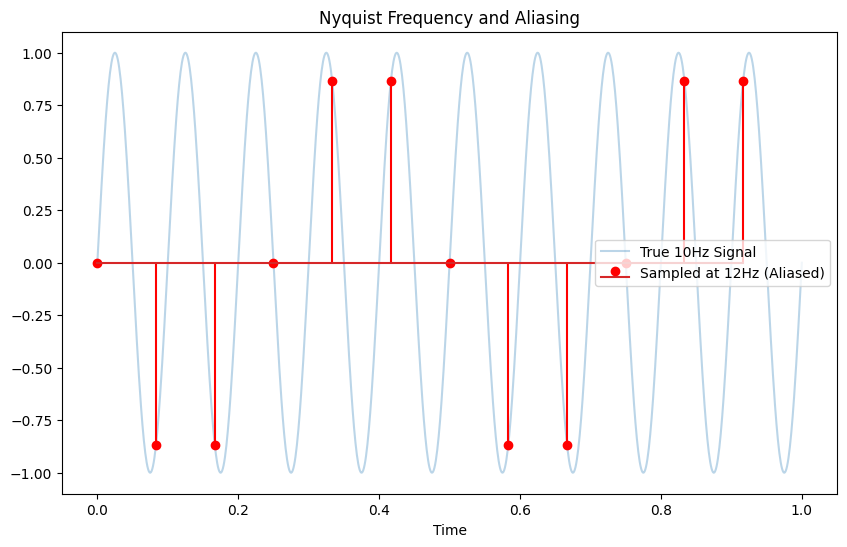

In [16]:
t_fine = np.linspace(0, 1, 1000)
f_signal = 10 # 10 Hz signal
y_true = np.sin(2 * np.pi * f_signal * t_fine)

# Low sampling rate (Aliasing!)
fs_low = 12
t_low = np.arange(0, 1, 1/fs_low)
y_low = np.sin(2 * np.pi * f_signal * t_low)

plt.plot(t_fine, y_true, label='True 10Hz Signal', alpha=0.3)
plt.stem(t_low, y_low, 'r', label='Sampled at 12Hz (Aliased)')

### STUDENT CODE HERE ###
# 1. Calculate the Nyquist frequency for a 12Hz sampling rate.
# 2. Add a title and labels to the plot.

nyquist = fs_low / 2
print(f"The Nyquist frequency is {nyquist} Hz. Since our signal is {f_signal} Hz, we expect aliasing.")


plt.title('Nyquist Frequency and Aliasing')
plt.xlabel('Time')
plt.legend()
plt.show()

##Task 4: Cross-Correlation (Travel Time)

**Concept:** Cross-correlation identifies the time lag between two signals. In seismology, we use this to find the travel time of a wave between two sensors.

Detected Time Delay: 0.394 seconds


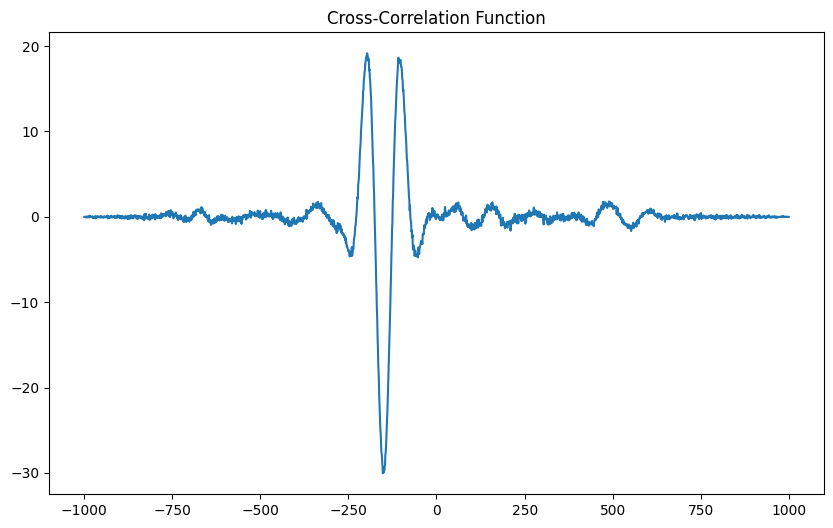

In [18]:
# Create a synthetic seismic pulse
t = np.linspace(0, 2, 1000)
def pulse(time, center):
    return np.exp(-(time-center)**2 / 0.01) * np.sin(2 * np.pi * 5 * time)

sensor1 = pulse(t, 0.5) + np.random.normal(0, 0.1, 1000)
sensor2 = pulse(t, 0.8) + np.random.normal(0, 0.1, 1000) # Delayed by 0.3s

### STUDENT CODE HERE ###
# Hint: Use np.correlate with mode='full'.
# The index of the maximum correlation value tells you the lag.

correlation = np.correlate(sensor1, sensor2, mode ='full')
lags = np.arange(-len(sensor1) + 1, len(sensor1))
best_lag_idx = np.argmax(correlation)
time_delay = lags[best_lag_idx] * (t[1] - t[0])

print(f"Detected Time Delay: {abs(time_delay):.3f} seconds")

plt.plot(lags, correlation)
plt.title("Cross-Correlation Function")
plt.show()

## Task 5: Frequency Domain - Power Spectral Density (PSD)
**Concept:** Lecture 22 explains that a Power Spectrum pulls apart "composite" signals to reveal hidden periodicities (like the 24-hour cycle vs. 365-day cycle). In seismology, we use PSDs to distinguish between seismic events and background "ambient noise."

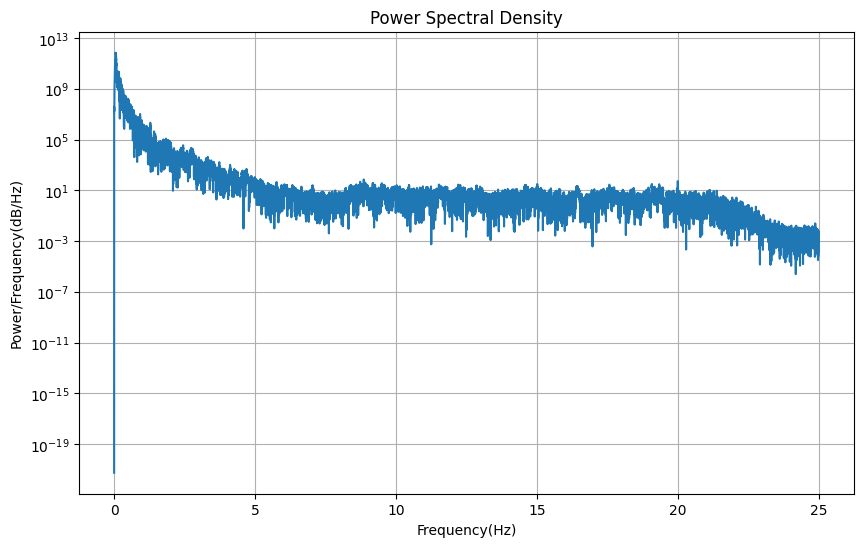

In [24]:
from obspy.core.inventory import Frequency
# Fetching data for a recent event using ObsPy
client = Client("IRIS")
starttime = obspy.UTCDateTime("2023-07-16T06:48:00") # M7.2 Alaska Event
st = client.get_waveforms("AK", "COLD", "", "BHZ", starttime, starttime + 600)
tr = st[0]

# Pre-processing: Always detrend and taper before spectral analysis
tr.detrend('linear')
tr.taper(0.05)

### STUDENT CODE HERE ###
# 1. Use scipy.signal.periodogram to calculate the PSD.
# 2. Plot the result on a log-log or semilogy scale.
# Hint: freq, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

freqs, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)
plt.semilogy(freqs, psd)
plt.title('Power Spectral Density')
plt.xlabel('Frequency(Hz)')
plt.ylabel('Power/Frequency(dB/Hz)')
plt.grid(True)
plt.show()

## Task 6: Time-Frequency Analysis - Spectrograms
**Concept:** A Power Spectrum (PSD) tells you *what* frequencies exist in the data, but a **Spectrogram** tells you *when* those frequencies occur. This is critical for identifying the arrival of different seismic phases (P-waves vs. S-waves).

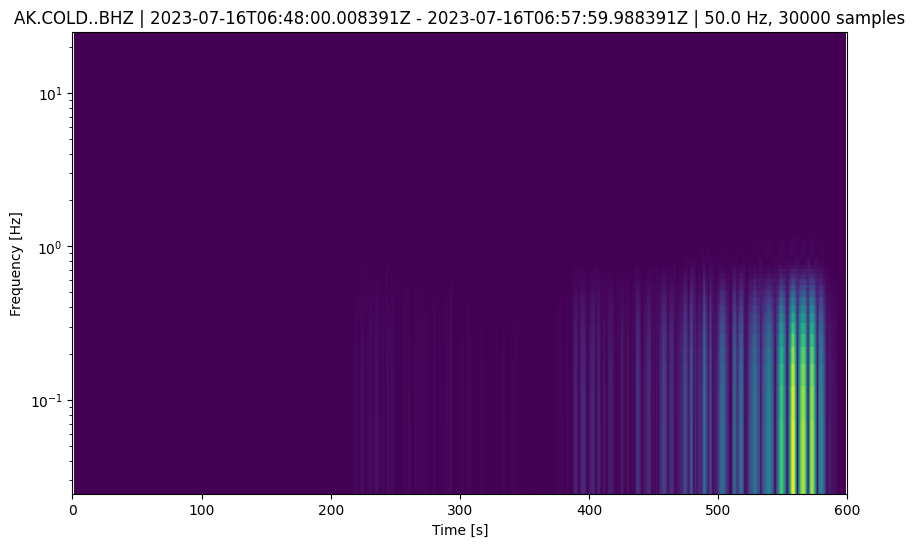

In [26]:
### STUDENT CODE HERE ###
# Hint: ObsPy Trace objects have a built-in .spectrogram() method.
# Apply it to the trace 'tr' we downloaded in the previous cell.
# Use 'log=True' in the spectrogram method to see the earthquake energy clearly.

tr.spectrogram(log=True)

##Task 7: Wavelet Transform

**Concept** A wavelet transform is roughly equivalent to a spectrogram, except analysis is performed in the time domain.

**Task:** Write all of the code to perform a wavelet transform on the trace from Tasks 5 and 6 and plot them. Perform two different wavelet transforms for different wavelet parameters (minimum and maximum frequencies

The resource found here shows how to do this in obspy: https://docs.obspy.org/archive/stable/tutorial/code_snippets/continuous_wavelet_transform.html

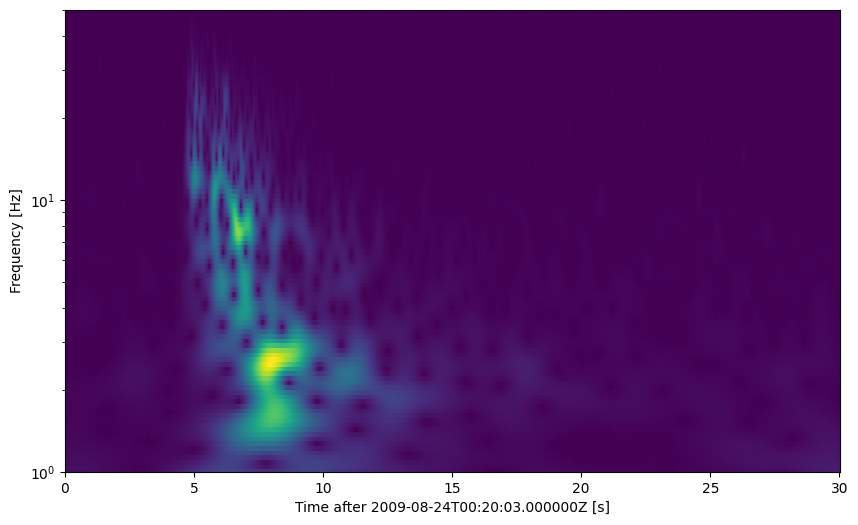

In [27]:
### STUDENT CODE HERE ###

import numpy as np
import matplotlib.pyplot as plt

import obspy
from obspy.imaging.cm import obspy_sequential
from obspy.signal.tf_misfit import cwt


st = obspy.read()
tr = st[0]
npts = tr.stats.npts
dt = tr.stats.delta
t = np.linspace(0, dt * npts, npts)
f_min = 1
f_max = 50

scalogram = cwt(tr.data, dt, 8, f_min, f_max)

fig = plt.figure()
ax = fig.add_subplot(111)

x, y = np.meshgrid(
    t,
    np.logspace(np.log10(f_min), np.log10(f_max), scalogram.shape[0]))

ax.pcolormesh(x, y, np.abs(scalogram), cmap=obspy_sequential)
ax.set_xlabel("Time after %s [s]" % tr.stats.starttime)
ax.set_ylabel("Frequency [Hz]")
ax.set_yscale('log')
ax.set_ylim(f_min, f_max)
plt.show()




## Lab Questions for Submission

### Question 1: Power Spectra
Based on your PSD plot in Task 5, you likely see a high-energy peak at very low frequencies (below 1 Hz) and a drop-off at higher frequencies. In the context of Lecture 22, why is the frequency domain more useful than the time domain for identifying a "dominant period" in noisy data?

**The frequency domain is more useful because it can isolate our desired frequencies from our data. It seperates it from the "noisy data"**

### Question 2: Spectrograms
Compare the static PSD plot from Task 5 to the Spectrogram in Task 6.
* Which plot better illustrates a signal whose frequency content changes over time?
* If you see a vertical "blast" of energy across many frequencies at a specific time, what does that represent in the seismogram?

**The PSD plot from task 5 better illustrates the frequency changes over time because it shows cleaner lines.**

**A vertical blast at a specific time represents a large powerful effect over a very short period of time. The effect could be an earthquake, or even just movement of a seismogram by a human.**

### Question 3: Wavelet Transforms
Lecture 22 mentions **Wavelet Transforms** as another technique for frequency analysis.
* **Hint:** Unlike the Fourier Transform (which uses infinite sines and cosines), Wavelets use short-duration "pulses."
* **Question:** Why might a Wavelet Transform be superior to a standard Fourier Transform for a seismic signal that contains sudden, short-lived "jolts" (like a rockfall or an explosion)?

**The wavelet transform can be better because the pulses are one time jolts and the event can be easily pointed out compared to a continous pattern of sine waves.**

### Question 4: Filtering
If you were looking for **Earth Tides** (very slow deformations with a period of ~12 hours), would you use a High-Pass or a Low-Pass filter to remove the "noise" of earthquakes and traffic? Why?

**I would use a high-pass filter because the tides are a low frequency signal and we want to remove all the high frequency noise from the data set.**